In [1]:
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{lmodern}'  # Usar Latin Modern Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Latin Modern Roman']
import numpy as np
from tensorflow import keras
#sns.set_style('dark')
plt.rcParams['font.size'] = 16
import json
import os
import copy
from IPython.display import display, HTML

# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import r2_score

import scipy as sp
from scipy.optimize import curve_fit

import uproot
import awkward as ak

import awkward as ak
import matplotlib.pyplot as plt
import hist
import math
import numpy as np
import vector
import pylhe
import seaborn as sns
from matplotlib import colormaps

In [2]:
os.getcwd()

'/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_Global/notebooks'

# Signal events for 2l

## Read in the signal

In [3]:
fileg = "../MadGraph/ppZZjj2l/Events/run_03/unweighted_events.lhe"
events = pylhe.to_awkward(pylhe.read_lhe_with_attributes(fileg))

Identify the particles

In [4]:
j1=events.particles.vector[:,-2]
j2=events.particles.vector[:,-1]
Z1=events.particles.vector[:,2]
Z2=events.particles.vector[:,3]
lp=events.particles.vector[:,-4]
lm=events.particles.vector[:,-3]
nu1=events.particles.vector[:,-6]
nu2=events.particles.vector[:,-5]

In [5]:
# invariant jet mass
mjj = (j1+j2).mass

In [6]:
# invariant mass of the ZZ pair (should be equivalent to the sum of all the leptons and neutrinos)
mZZ = (Z1+Z2).mass
mllnunu = (lp+lm+nu1+nu2).mass

Function to read in the total cross section and total number of events from the lhe file. Note that for different processes the rows may shift.

In [7]:
def read_sigma_nevents(filename):
    with open(filename,'r') as f:
        data = f.readlines()
    f.close()
    sigma = float(data[439].split(' ')[13])
    nevents = float(data[151].split(' ')[2])
    return sigma, nevents

In [8]:
(sigma, Ntot) = read_sigma_nevents(fileg)

In [9]:
sigma

0.000375345983604372

In [10]:
Ntot

100000.0

## Data Visualisation!

delta R separation between the neutrinos

In [11]:
min(nu1.deltaR(nu2))

0.05908009764022057

In [12]:
max(nu1.deltaR(nu2))

7.023181680658136

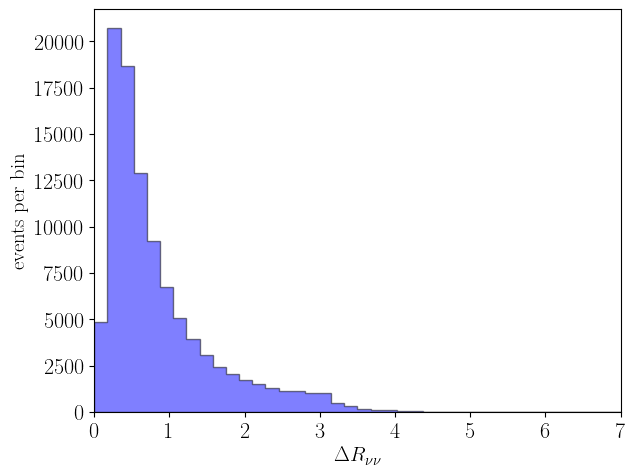

In [13]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(nu1.deltaR(nu2),bins=40,range=(0,7),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 7)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{\nu\nu}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

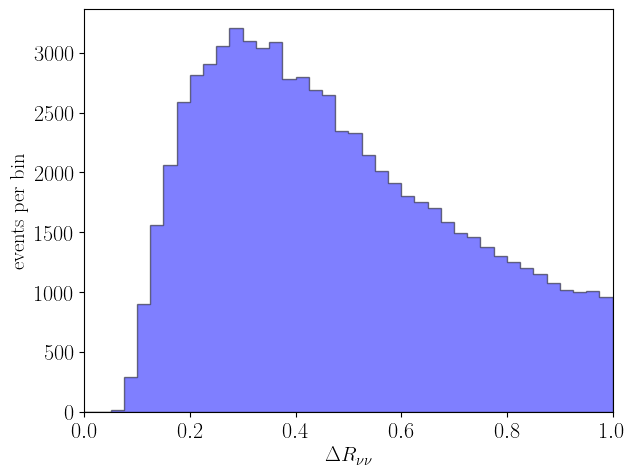

In [14]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins)
n_dR, bins_dR, _ =plt.hist(nu1.deltaR(nu2),bins=40,range=(0,1),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{\nu\nu}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

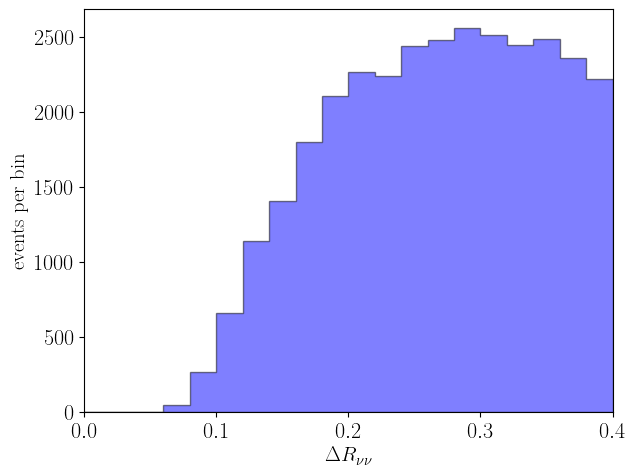

In [15]:
n_J, bins_J, _ =plt.hist(nu1.deltaR(nu2),bins=20,range=(0,0.4),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 0.4)
plt.tight_layout()
plt.xlabel(r'$\Delta R_{\nu\nu}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [16]:
# fraction of the events that results in the fat jet topology
n_J.sum()/Ntot

0.31414

In [17]:
# resolved regions
mZZ_res = [mZZ[i] for i in range(len(events)) if (nu1.deltaR(nu2))[i] > 0.4];

In [18]:
# fat jet region
mZZ_fat = [mZZ[i] for i in range(len(events)) if (nu1.deltaR(nu2))[i] < 0.4];

Focus on the resolved region with $\Delta R_{\nu\nu} > 0.4$ first

# Invariant mass of the ZZ $m_{lljj}$ in the resolved region

In [101]:
mZZ_bins = (0,200,400,600,800,1000,1200,1400,1600,1800,2000);

In [102]:
mZZ_bin_center = (100,300,500,700,900,1100,1300,1500,1700,1900);

In [103]:
min(mZZ_res)

169.4719077247199

In [104]:
max(mZZ_res)

5844.716057327482

In [105]:
min(mllnunu)

169.47190764909578

In [106]:
max(mllnunu)

7212.827765539889

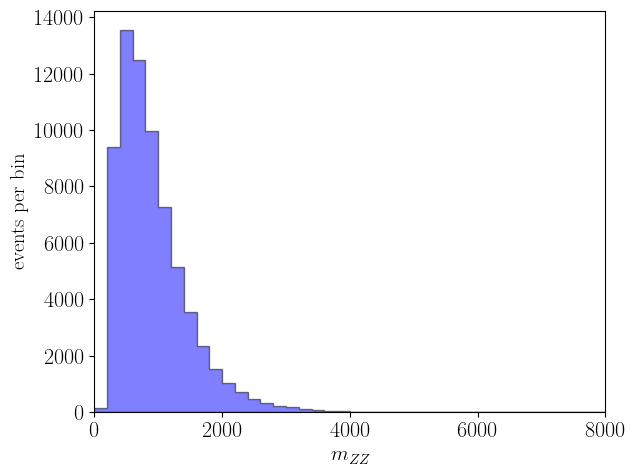

In [107]:
# in arbitrary bins
n, bins, _ =plt.hist(mZZ_res,bins=40,range=(0,8000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 8000)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

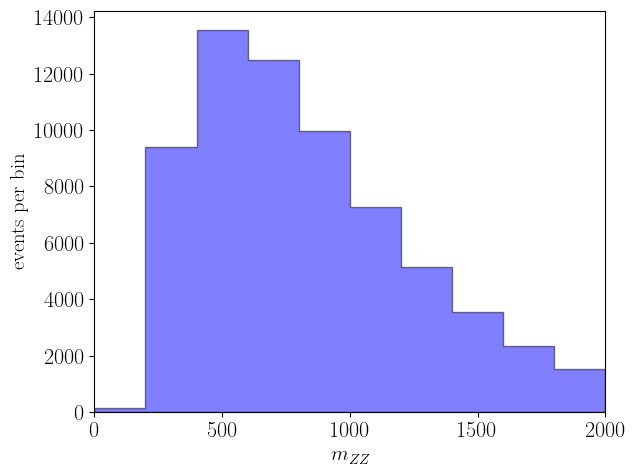

In [108]:
# in ATLAS bins
n, bins, _ =plt.hist(mZZ_res,bins=mZZ_bins,range=(0,2000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 2000)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [109]:
# calculate the efficiency as the number of events that fall into the bins
eps = n.sum()/Ntot

In [110]:
eps

0.65331

## Read in the digitised data and background from Figure 10g in the auxiliary material

In [111]:
#background 
background = pd.read_csv('../MadGraph/ppZZjj2l/2leptonBG.csv', sep=';', nrows=10, header=0).values[:,1]

In [112]:
background

array([2.08972980e+03, 1.85600871e+04, 4.39609863e+03, 1.26400856e+03,
       4.33284660e+02, 1.81645805e+02, 7.79336508e+01, 3.72143793e+01,
       1.54075996e+01, 7.66592747e+00])

In [113]:
data_by_BG = pd.read_csv('../MadGraph/ppZZjj2l/2leptonData_BG_point.csv', sep=';', nrows=10, header=0).values[:,1]

In [114]:
data_by_BG

array([1.03143656, 1.03632164, 1.03650878, 1.0191627 , 0.98947915,
       0.87018235, 0.71888545, 0.76904622, 0.40182474, 0.79584935])

In [115]:
unc_upper_by_BG = pd.read_csv('../MadGraph/ppZZjj2l/2leptonData_BG_upper.csv', sep=';', nrows=10, header=0).values[:,1]

In [116]:
unc_upper_by_BG

array([1.11203186, 1.12123818, 1.11998572, 1.09593824, 1.06988732,
       0.95829241, 0.83254618, 0.94107109, 0.64455122, 1.26395622])

In [117]:
unc_lower_by_BG = pd.read_csv('../MadGraph/ppZZjj2l/2leptonData_BG_lower.csv', sep=';', nrows=10, header=0).values[:,1]

In [118]:
unc_lower_by_BG

array([0.95071528, 0.96154954, 0.96048422, 0.93856617, 0.90825762,
       0.80355124, 0.62776899, 0.6284576 , 0.24802292, 0.48148192])

In [119]:
data = np.multiply(data_by_BG, background)
unc_upper = np.multiply(unc_upper_by_BG, background)
unc_lower = np.multiply(unc_lower_by_BG, background)

In [120]:
unc_upper

array([2.32384612e+03, 2.08102782e+04, 4.92356767e+03, 1.38527532e+03,
       4.63565764e+02, 1.74069797e+02, 6.48833631e+01, 3.50213765e+01,
       9.93098713e+00, 9.68939672e+00])

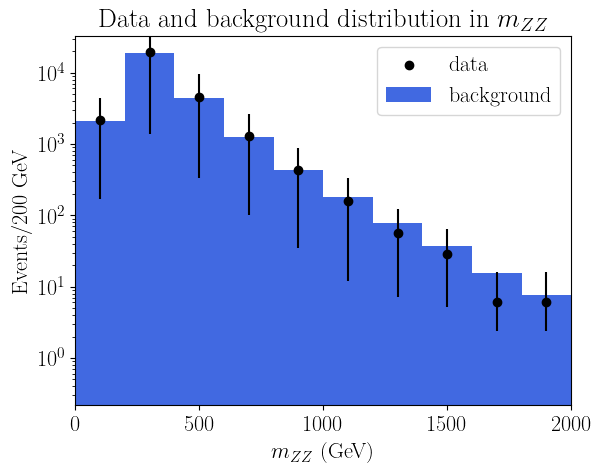

In [121]:
plt.bar(mZZ_bins[:-1], background, width=np.diff(mZZ_bins), align='edge', alpha=1, color='royalblue',label='background')
plt.scatter(mZZ_bin_center, data, color='black', label='data')
plt.xlim(0,2000)
#plt.ylim(0,5)
plt.yscale("log")
plt.errorbar(mZZ_bin_center, data, [unc_lower, unc_upper], color='black', alpha=1,fmt='none')
plt.xlabel('$m_{ZZ}$ (GeV) ')
plt.ylabel(r'Events/200 GeV')
plt.title("Data and background distribution in $m_{ZZ}$")
plt.legend()

In [122]:
(data*np.diff(mZZ_bins)).sum()

5583639.396660314

## Signal events in the right bins, normalised distribution 

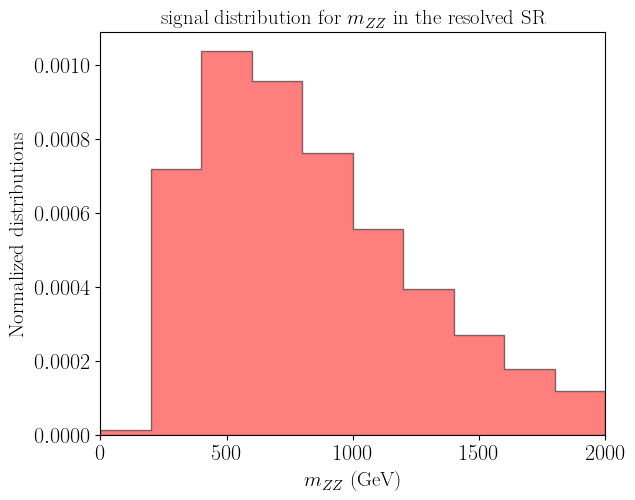

In [123]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins))
n_signal, bins, _ = plt.hist(mZZ_res,bins=mZZ_bins,range=(0,2000),label='non-linear axion', alpha=0.5,density=True,color = "red", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 2000)
#plt.yscale("log")
plt.tight_layout()
plt.title(r'signal distribution for $m_{ZZ}$ in the resolved SR ',fontsize=15)
plt.xlabel(r'$m_{ZZ}$ (GeV)',fontsize=15)
plt.ylabel(r'Normalized distributions',fontsize=15)
#plt.savefig("mHHdist.pdf")
plt.show()

In [124]:
(n_signal*np.diff(mZZ_bins)).sum()

0.9999999999999999

ATLAS also gives the data and background in events per bin and per bin width, meaning that we do not have to multiply with the bin width to compare the signal.

## Compare signal with data and background


In [125]:
# BR: factor of the branching ratios due to generating Z-> nu nu instead of Z-> jj
BR_Znunu = 0.2
BR_Zll = 0.101
BR_Zjj = 0.699

BR = BR_Zjj/BR_Znunu

In [126]:
# rescale the MG5 signal events to compare with the data: N_events = n_signal * lumi * sigma * eps * BR
# eps = efficiency to the bin selection = number of events that fall in the ATLAS bins/ number of all events
# sigma in lhe file: total cross section including BR sigma in pb


# careful! the lumi is given in fb^-1 but the cross section from MadGraphin pb, which explains the additional factor of 1000.
lumi = 140

N_events = n_signal*lumi*sigma*1000*eps*BR

In [127]:
N_events

array([0.00133151, 0.0862085 , 0.12442748, 0.11460184, 0.09144272,
       0.06665823, 0.04736509, 0.03245215, 0.02136847, 0.01406811])

In [128]:
data

array([2.15542372e+03, 1.92342199e+04, 4.55659482e+03, 1.28823037e+03,
       4.28726139e+02, 1.58064974e+02, 5.60253672e+01, 2.86195777e+01,
       6.19115475e+00, 6.10092338e+00])

In [129]:
# rescale for cW = 10:
sigma_cW1 = 0.022665 # taken from the fit in mathematica 
sigma_cW5 = 14.1656 # taken from the fit in mathematica 
sigma_cW10 = 226.65 # taken from the fit in mathematica

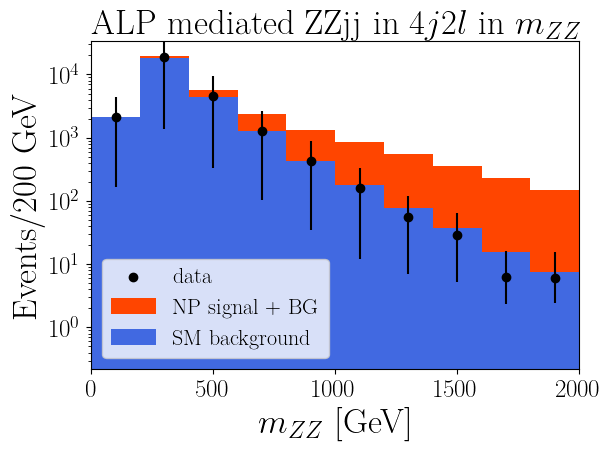

In [130]:
ax = plt.gca()
plt.bar(mZZ_bins[:-1], background+N_events*sigma_cW10/sigma_cW1, width=np.diff(mZZ_bins), align='edge', alpha=1, color='orangered', label='NP signal + BG')
plt.bar(mZZ_bins[:-1], background, width=np.diff(bins), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(0, 2000)
#plt.ylim(0,10000)
plt.yscale("log")
plt.xlabel('$m_{ZZ}$ [GeV]',fontsize=25)
plt.ylabel(r'Events/200 GeV', fontsize=25)
plt.errorbar(mZZ_bin_center, data, yerr=[unc_lower, unc_upper], color='black', alpha=1,fmt='none')
plt.scatter(mZZ_bin_center, data, color='black', label='data')
plt.legend(loc=3)
plt.title(r" ALP mediated ZZjj in $4j2l$ in $m_{ZZ}$", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_GLOBAL/Figures/ZZjj2l_res_cW10.pdf")
plt.show()

### Output data to Mathematica

In [50]:
# calculate the mean error from the upper and lower end
data_unc = (unc_upper-unc_lower)/2

In [51]:
# data
Mathematica_data = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data]) + "}" + ";"
print(Mathematica_data)

{2.1554*10^+03,1.9234*10^+04,4.5566*10^+03,1.2882*10^+03,4.2873*10^+02,1.5806*10^+02,5.6025*10^+01,2.8620*10^+01,6.1912*10^+00,6.1009*10^+00};


In [52]:
# data unc
Mathematica_data_unc = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_unc]) + "}" ";"
print(Mathematica_data_unc)

{1.6855*10^+02,1.4819*10^+03,3.5059*10^+02,9.9460*10^+01,3.5016*10^+01,1.4054*10^+01,7.9795*10^+00,5.8169*10^+00,3.0548*10^+00,2.9992*10^+00};


In [53]:
# background
Mathematica_background = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in background]) + "}" ";"
print(Mathematica_background)

{2.0897*10^+03,1.8560*10^+04,4.3961*10^+03,1.2640*10^+03,4.3328*10^+02,1.8165*10^+02,7.7934*10^+01,3.7214*10^+01,1.5408*10^+01,7.6659*10^+00};


In [54]:
# signal
N_signal = n_signal * lumi * sigma * 1000 * eps * BR
Mathematica_signal = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in N_signal]) + "}" ";"
print(Mathematica_signal)

{1.3315*10^-03,8.6208*10^-02,1.2443*10^-01,1.1460*10^-01,9.1443*10^-02,6.6658*10^-02,4.7365*10^-02,3.2452*10^-02,2.1368*10^-02,1.4068*10^-02};


In [55]:
# bin center
Mathematica_bin_center = "{" + ",".join(["{:.0f}".format(x) for x in mZZ_bin_center]) + "}" ";"
print(Mathematica_bin_center)

{100,300,500,700,900,1100,1300,1500,1700,1900};


# Invariant mass of the ZZ $m_{llJ}$ in the fat jet region

In [56]:
min(mZZ_fat)

187.32859074607774

In [57]:
max(mZZ_fat)

7212.827765497717

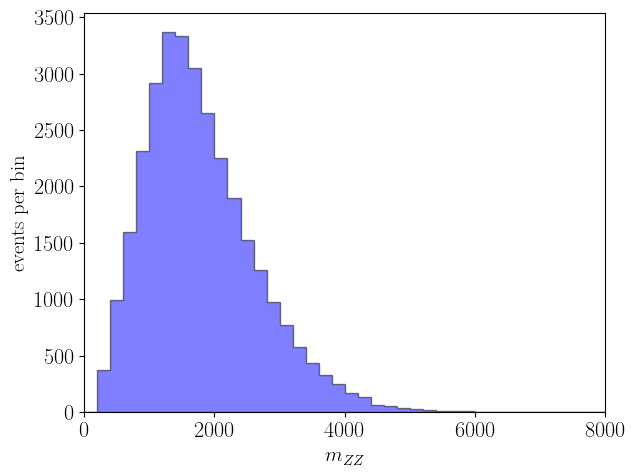

In [58]:
# in arbitrary bins
n, bins, _ =plt.hist(mZZ_fat,bins=40,range=(0,8000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 8000)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [59]:
mZZ_bins_fat = (200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000) # it's not possible to do the histogramm with interrupted bins. discard the last bin.

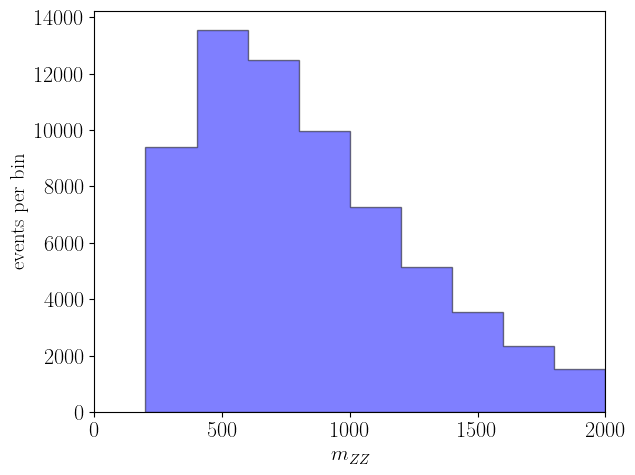

In [60]:
# in ATLAS bins
n, bins, _ =plt.hist(mZZ_res,bins=mZZ_bins_fat,range=(0,2000),label='non-linear axion', alpha=0.5,density=False,color = "blue", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 2000)
plt.tight_layout()
plt.xlabel(r'$m_{ZZ}$ ',fontsize=15)
plt.ylabel(r'events per bin',fontsize=15)
#plt.savefig("mgammagamma.pdf")
plt.show()

In [61]:
# calculate the efficiency as the number of events that fall into the bins
eps_fat = n.sum()/Ntot

In [62]:
eps_fat

0.65186

## Read in the digitised data and background from Figure 10i (or maybe 10h) in the auxiliary material

In [63]:
mZZ_bins_fat

(200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000)

In [64]:
mZZ_bins_fat = (200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000) # it's not possible to do the histogramm with interrupted bins. discard the last bin.

In [65]:
mZZ_bin_center_fat = (300,500,700,900,1100,1300,1500, 1700, 1900);

In [66]:
#background 
background_fat = pd.read_csv('../MadGraph/ppZZjj2l/2leptonBG_mergedHP.csv', sep=';', nrows=9, header=0).values[:,1]

In [67]:
len(background_fat)

9

In [68]:
background_fat

array([287.82172824, 384.92909914, 180.59102872,  65.08894968,
        22.42563382,  10.84350222,   4.46382742,   2.98904909,
         1.52997599])

In [69]:
# all but penultimate bin
data_by_BG_fat = pd.read_csv('../MadGraph/ppZZjj2l/2leptonData_BGpoint_mergedHP.csv', sep=';', nrows=9, header=0).values[:,1]

In [70]:
# insert "0" in the 8th bin
data_by_BG_fat = np.insert(data_by_BG_fat, 7, 0)

In [71]:
data_by_BG_fat

array([1.08501694, 1.05451913, 0.86015577, 0.78790736, 1.44367698,
       0.92600919, 0.45531847, 0.        , 0.65576938])

In [72]:
# only first 7 bins, the last two are separate 
unc_upper_by_BG_fat = pd.read_csv('../MadGraph/ppZZjj2l/2leptonData_BGupper_mergedHP.csv', sep=';', nrows=7, header=0).values[:,1]

In [73]:
# only first 7 bins, the last two are separate 
unc_lower_by_BG_fat = pd.read_csv('../MadGraph/ppZZjj2l/2leptonData_BGlower_mergedHP.csv', sep=';', nrows=7, header=0).values[:,1]

In [74]:
# append the uncertainty for the penultimate bin
unc_lower_by_BG_fat = np.append(unc_lower_by_BG_fat, 0.8422629989495791)

In [75]:
# append the uncertainty for the penultimate bin
unc_upper_by_BG_fat = np.append(unc_upper_by_BG_fat, 1.1720849239085869)

In [76]:
unc_lower_by_BG_fat

array([0.99174011, 0.96985062, 0.78335701, 0.67698275, 1.19059257,
       0.63726173, 0.16484887, 0.842263  ])

In [77]:
len(data_by_BG_fat)

9

In [78]:
len(unc_upper_by_BG_fat)

8

In [79]:
len(unc_lower_by_BG_fat)

8

In [80]:
data_fat = np.multiply(data_by_BG_fat, background_fat)

In [81]:
unc_upper_fat = np.multiply(unc_upper_by_BG_fat, background_fat[:-1])
unc_lower_fat = np.multiply(unc_lower_by_BG_fat, background_fat[:-1])

In [82]:
unc_lower_fat = np.append(unc_lower_fat, 0.1743207472846006)

In [83]:
unc_upper_fat = np.append(unc_upper_fat, 3.2499595399356793)

In [84]:
unc_lower_fat

array([2.85444353e+02, 3.73323725e+02, 1.41467247e+02, 4.40640960e+01,
       2.66997931e+01, 6.91014903e+00, 7.35856925e-01, 2.51756545e+00,
       1.74320747e-01])

In [85]:
# calculate the mean error from the upper and lower end
data_unc_fat = (unc_upper_fat-unc_lower_fat)/2

In [86]:
len(data_unc_fat)

9

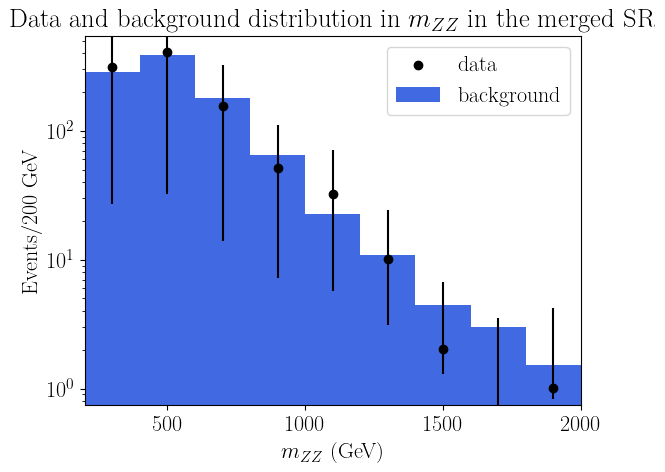

In [87]:
plt.bar(mZZ_bins_fat[:-1], background_fat, width=np.diff(mZZ_bins_fat), align='edge', alpha=1, color='royalblue',label='background')
plt.scatter(mZZ_bin_center_fat, data_fat, color='black', label='data')
plt.xlim(200,2000)
#plt.ylim(0,5)
plt.yscale("log")
plt.errorbar(mZZ_bin_center_fat, data_fat, [unc_lower_fat, unc_upper_fat], color='black', alpha=1,fmt='none')
plt.xlabel('$m_{ZZ}$ (GeV) ')
plt.ylabel(r'Events/200 GeV')
plt.title("Data and background distribution in $m_{ZZ}$ in the merged SR")
plt.legend()

In [88]:
(data_fat*np.diff(mZZ_bins_fat)).sum()

194055.87112148618

## Signal events in the right bins, normalised distribution

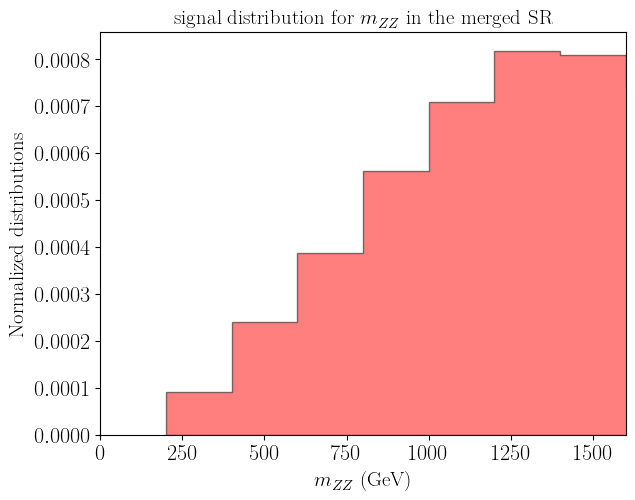

In [89]:
# histogram for NP signal (n = number of events per bin)
# density=True gives bin's raw count divided by the total number of counts and the bin width, i.e. density = counts / (sum(counts) * np.diff(bins))
n_signal_fat, bins, _ = plt.hist(mZZ_fat,bins=mZZ_bins_fat,range=(0,1600),label='non-linear axion', alpha=0.5,density=True,color = "red", ec="k",histtype='stepfilled',log=False)
plt.xlim(0, 1600)
#plt.yscale("log")
plt.tight_layout()
plt.title(r'signal distribution for $m_{ZZ}$ in the merged SR ',fontsize=15)
plt.xlabel(r'$m_{ZZ}$ (GeV)',fontsize=15)
plt.ylabel(r'Normalized distributions',fontsize=15)
#plt.savefig("mHHdist.pdf")
plt.show()

In [90]:
(n_signal_fat*np.diff(mZZ_bins_fat)).sum()

1.0

## Compare signal with data and background

In [91]:
# BR: factor of the branching ratios due to generating Z-> nu nu instead of Z-> jj
BR_Znunu = 0.2
BR_Zll = 0.101
BR_Zjj = 0.699

BR = BR_Zjj/BR_Znunu

In [92]:
# rescale the MG5 signal events to compare with the data: N_events = n_signal * lumi * sigma * eps * BR
# eps = efficiency to the bin selection = number of events that fall in the ATLAS bins/ number of all events
# sigma in lhe file: total cross section including BR sigma in pb


# careful! the lumi is given in fb^-1 but the cross section from MadGraphin pb, which explains the additional factor of 1000.
lumi = 140

N_events_fat = n_signal_fat*lumi*sigma*1000*eps*BR

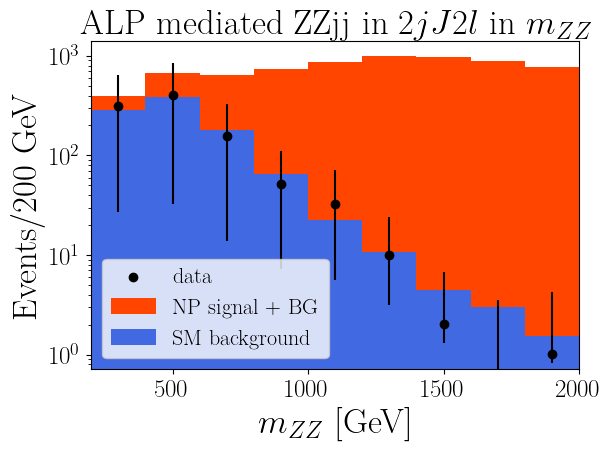

In [95]:
ax = plt.gca()
plt.bar(mZZ_bins_fat[:-1], background_fat+N_events_fat*sigma_cW10/sigma_cW1, width=np.diff(mZZ_bins_fat), align='edge', alpha=1, color='orangered', label='NP signal + BG')
plt.bar(mZZ_bins_fat[:-1], background_fat, width=np.diff(mZZ_bins_fat), align='edge', alpha=1, color='royalblue',label='SM background')
plt.xlim(200, 2000)
#plt.ylim(0,10000)
plt.yscale("log")
plt.xlabel('$m_{ZZ}$ [GeV]',fontsize=25)
plt.ylabel(r'Events/200 GeV', fontsize=25)
plt.errorbar(mZZ_bin_center_fat, data_fat, yerr=[unc_lower_fat, unc_upper_fat], color='black', alpha=1,fmt='none')
plt.scatter(mZZ_bin_center_fat, data_fat, color='black', label='data')
plt.legend(loc=3)
plt.title(r" ALP mediated ZZjj in $2jJ2l$ in $m_{ZZ}$", fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.savefig("/Users/esser/Documents/PROJECTS/ALPsPheno/ALP GLOBAL/github/ALP_Global/Figures/ZZjj2l_merged_cW10.pdf")
plt.show()

### Output data to Mathematica

In [94]:
# calculate the mean error from the upper and lower end
data_unc_fat = (unc_upper_fat-unc_lower_fat)/2

In [357]:
# data
Mathematica_data = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_fat]) + "}" + ";"
print(Mathematica_data)

{3.1229*10^+02,4.0592*10^+02,1.5534*10^+02,5.1284*10^+01,3.2375*10^+01,1.0041*10^+01,2.0325*10^+00,0.0000*10^+00,1.0033*10^+00};


In [358]:
# data unc
Mathematica_data_unc = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in data_unc_fat]) + "}" ";"
print(Mathematica_data_unc)

{2.5299*10^+01,3.3763*10^+01,1.4535*10^+01,7.9864*10^+00,6.2058*10^+00,3.7064*10^+00,1.9733*10^+00,4.9293*10^-01,1.5378*10^+00};


In [359]:
# background
Mathematica_background = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in background_fat]) + "}" ";"
print(Mathematica_background)

{2.8782*10^+02,3.8493*10^+02,1.8059*10^+02,6.5089*10^+01,2.2426*10^+01,1.0844*10^+01,4.4638*10^+00,2.9890*10^+00,1.5300*10^+00};


In [360]:
# signal
N_signal_fat = n_signal_fat * lumi * sigma * 1000 * eps_fat * BR
Mathematica_signal = "{" + ",".join([f"{x:.4e}".replace('e', '*10^') for x in N_signal_fat]) + "}" ";"
print(Mathematica_signal)

{1.0760*10^-02,2.8790*10^-02,4.6296*10^-02,6.7350*10^-02,8.4828*10^-02,9.7885*10^-02,9.6925*10^-02,8.8608*10^-02,7.7151*10^-02};


In [361]:
# bin center
Mathematica_bin_center = "{" + ",".join(["{:.0f}".format(x) for x in mZZ_bin_center_fat]) + "}" ";"
print(Mathematica_bin_center)

{300,500,700,900,1100,1300,1500,1700,1900};
